In [2]:
#Import necessary libraries
from scipy.stats import qmc
import numpy as np
import pandas as pd

from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

In [3]:
#Function 3
#Extracting updated data and turning it into a pandas dataframe
data = pd.read_csv('Data/Week 6 - Function 3.csv') 
columns = ['Input 1', 'Input 2', 'Input 3', 'Outputs']
#Remove columns with NaN values
data = data.dropna(axis = 1)
data.columns = columns
#Add Week 7's data to our pandas dataframe
new_data7 = np.array([0.583115, 0.709624, 0.569389,-0.04490503647909851])
data.loc[len(data)] = new_data7
data





,Input 1,Input 2,Input 3,Outputs
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


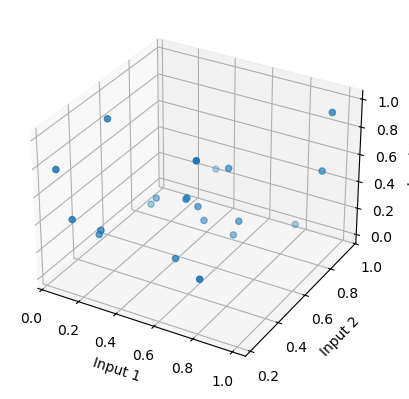

In [4]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2', 'Input 3']])
Y = np.array(data[['Outputs']])

#Visualise already explored points
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X[:,0], X[:,1], X[:,2])

ax.set_xlabel("Input 1")
ax.set_ylabel("Input 2")
ax.set_zlabel("Input 3")

plt.show()

In [5]:
# Find the pearson correlations matrix
data.corr(method = 'pearson')

,Input 1,Input 2,Input 3,Outputs
Input 1,1.000000,0.550243,0.034534,-0.126230
Input 2,0.550243,1.000000,-0.189147,-0.088413
Input 3,0.034534,-0.189147,1.000000,-0.570363
Outputs,-0.126230,-0.088413,-0.570363,1.000000


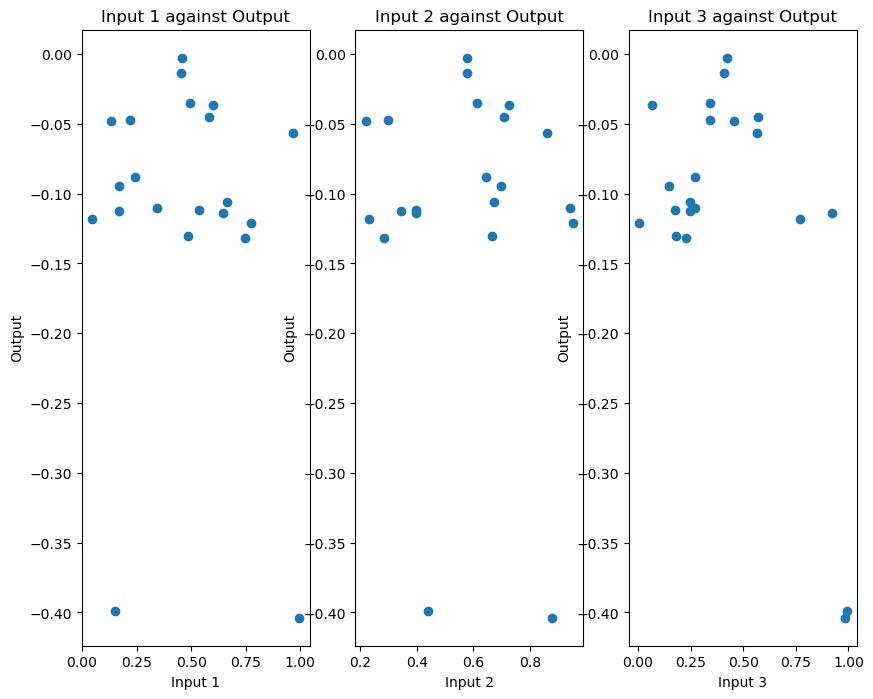

In [6]:
#Plotting each Input against the output
fig, ax = plt.subplots(1,3, figsize = (10,8))
ax[0].scatter(X[:,0], Y)
ax[1].scatter(X[:,1], Y)
ax[2].scatter(X[:,2], Y)

#Creating titles and axis labels
ax[0].set_title('Input 1 against Output')
ax[1].set_title('Input 2 against Output')
ax[2].set_title('Input 3 against Output')

ax[0].set_xlabel('Input 1')
ax[0].set_ylabel('Output')

ax[1].set_xlabel('Input 2')
ax[1].set_ylabel('Output')

ax[2].set_xlabel('Input 3')
ax[2].set_ylabel('Output')
plt.show()

In [7]:
#We now use random forest regression to generate a list of promising points for a GP
#to evaluate
from sklearn.ensemble import RandomForestRegressor
#Using randomized search CV for light hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features": [0.5, 0.7, 1.0]
}

rf = RandomForestRegressor(
    n_jobs=-1,
    random_state=42
)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1, random_state = 42)

search.fit(X, Y.ravel())

rf_best = search.best_estimator_
print("Tuned RF Model:", rf_best)


Tuned RF Model: RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)


In [11]:
#Use latin hypercube sampling to create a grid 
d = 3
n = 20000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n)   # samples in [0,1]^d

#Use random forest model to outputs from the grid
Y_pred = rf_best.predict(grid)

#Select the top 200 points
n_select = 200
top_idx = np.argsort(Y_pred)[-n_select:]
X_candidates = grid[top_idx]

In [9]:
#We now set the Kernel to be the Matern Kernel
nu = 2.5
kernel = Matern(length_scale=1.0, length_scale_bounds= (1e-2,1e1), nu = nu)
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)

gp.fit(X,Y)



#fit GP to candidate points suggested by Random Forest model
mu, std = gp.predict(X_candidates, return_std = True)

#fit GP to candidate points generated over the entire domain
mu_grid, std_grid = gp.predict(grid, return_std = True)

In [10]:
#Calculate UCB 
beta = 1.96 #set exploration parameter
UCB = mu + beta*std 
UCB_grid = mu_grid + beta*std_grid
#Find point selected by random forest model that maximizes UCB 
X_next = X_candidates[np.argmax(UCB)]
#Find point in the entire domain that maximizes UCB
X_next_grid = grid[np.argmax(UCB_grid)]
print("Random Forest Hybrid model next suggested point:", np.round(X_next,6))
print("Pure GP model next suggested point:", np.round(X_next_grid,6))

Random Forest Hybrid model next suggested point: [0.591817 0.469104 0.42563 ]
Pure GP model next suggested point: [0.595952 0.45556  0.525572]
